# Weak-scale-prior BQR-DN V3.1 training on VOC2007

Trains `bqr_dn_v3_1` with the V3 five-point sampler and a reduced scale-prior multiplier: $A_{l,k}=Q_{l,k}+0.5S_l$. All other V3 settings remain unchanged.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
from gt_guided_dino.api import ExperimentConfig, train
from gt_guided_dino.visualization import plot_history

print('torch:', torch.__version__, 'cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

d:\BQR_DETR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.12.1+cu126 cuda: True
NVIDIA GeForce RTX 3060


In [2]:
config = ExperimentConfig(
    data_root=PROJECT_ROOT / 'VOC2007',
    output_root=PROJECT_ROOT / 'artifacts',
    method='bqr_dn_v3_1',
    epochs=12,
    train_limit=1000,
    lr_drop_epoch=11,
    bqr_enabled=True,
    bqr_dn_weight=1.0,
    bqr_points_per_level=5,
    bqr_gate_bias=-2.0,
    bqr_scale_aware=True,
    bqr_target_cells=4.0,
    bqr_scale_sigma=0.8,
    bqr_scale_weight=0.5,
    bqr_scale_logit_floor=-4.0,
)
assert config.num_feature_levels == 4
assert config.bqr_points_per_level == 5
assert config.bqr_scale_weight == 0.5
assert config.run_dir == PROJECT_ROOT / 'artifacts' / 'bqr_dn_v3_1' / 'seed_42'
config

ExperimentConfig(data_root=WindowsPath('D:/BQR_DETR/VOC2007'), output_root=WindowsPath('D:/BQR_DETR/artifacts'), torch_cache=WindowsPath('D:/BQR_DETR/weights/torch'), method='bqr_dn_v3_1', seed=42, train_limit=1000, val_limit=None, epochs=12, batch_size=1, accumulation_steps=4, num_workers=0, precision='fp16', lr=0.0001, backbone_lr=1e-05, weight_decay=0.0001, grad_clip=0.1, lr_drop_epoch=11, lr_drop_gamma=0.1, save_every=1, num_queries=900, hidden_dim=256, enc_layers=6, dec_layers=6, dim_feedforward=2048, num_feature_levels=4, dn_number=100, train_scales=(480, 512, 544, 576, 608, 640, 672, 704, 736, 768, 800), train_max_size=1333, crop_resize_scales=(400, 500, 600), crop_min_size=384, crop_max_size=600, use_random_crop=True, val_size=800, val_max_size=1333, aux_weight=1.0, aux_l1_coef=5.0, aux_giou_coef=2.0, sampling_points_per_level=4, bqr_enabled=True, bqr_dn_weight=1.0, bqr_points_per_level=5, bqr_gate_bias=-2.0, bqr_content_attention=True, bqr_attention_dim=64, bqr_content_scale_i

In [3]:
# Resumes artifacts/bqr_dn_v3_1/seed_42/checkpoints/latest.pt when present.
history = train(config, resume=True)
history[-1]

epoch=05 loss=18.1059 lr=1.00e-04 seconds=429.5


epoch=06 loss=16.6694 lr=1.00e-04 seconds=389.4


epoch=07 loss=15.9951 lr=1.00e-04 seconds=394.4


epoch=08 loss=15.1038 lr=1.00e-04 seconds=396.2


epoch=09 loss=14.2807 lr=1.00e-04 seconds=398.8


epoch=10 loss=13.7022 lr=1.00e-04 seconds=404.7


epoch=11 loss=13.2675 lr=1.00e-04 seconds=435.9


epoch=12 loss=11.6641 lr=1.00e-05 seconds=434.5


{'epoch': 12,
 'lr': 1e-05,
 'loss': 11.664119427263737,
 'batches': 1000,
 'optimizer_steps': 250,
 'seconds': 434.4602215,
 'peak_cuda_mb': 5973.60986328125,
 'loss_ce': 0.300706125757657,
 'loss_bbox': 0.06085628501698375,
 'loss_giou': 0.1332098404727876,
 'loss_ce_dn': 0.05850031872803811,
 'loss_bbox_dn': 0.07208781383745372,
 'loss_giou_dn': 0.1364624011144042,
 'bqr_valid_queries': 197.582,
 'bqr_gate_mean': 0.8213998130559921,
 'bqr_offset_abs_mean': 0.10450252490490675,
 'bqr_attention_entropy': 2.6181143014431,
 'bqr_region_norm': 13.550657620429993,
 'bqr_fusion_delta_norm': 9.002964507341385,
 'bqr_top1_attention': 0.15517183484882116,
 'bqr_query_attention_entropy': 2.922957267284393,
 'bqr_final_attention_entropy': 2.6181143014431,
 'bqr_scale_prior_entropy': 0.7312808490693569,
 'bqr_scale_logit_span': 3.7210245716571806,
 'bqr_center_attention': 0.24000002171099186,
 'weighted_ce_total': 2.83638265368063,
 'weighted_bbox_total': 4.907403015162796,
 'weighted_giou_total

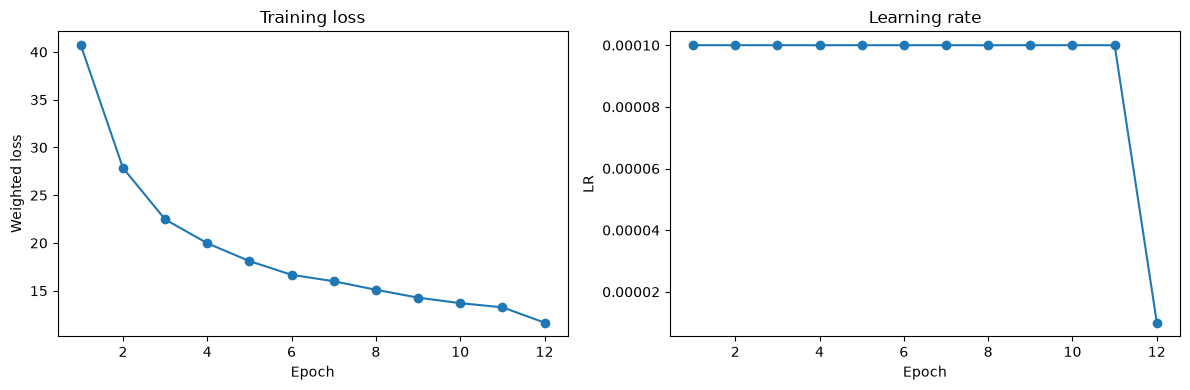

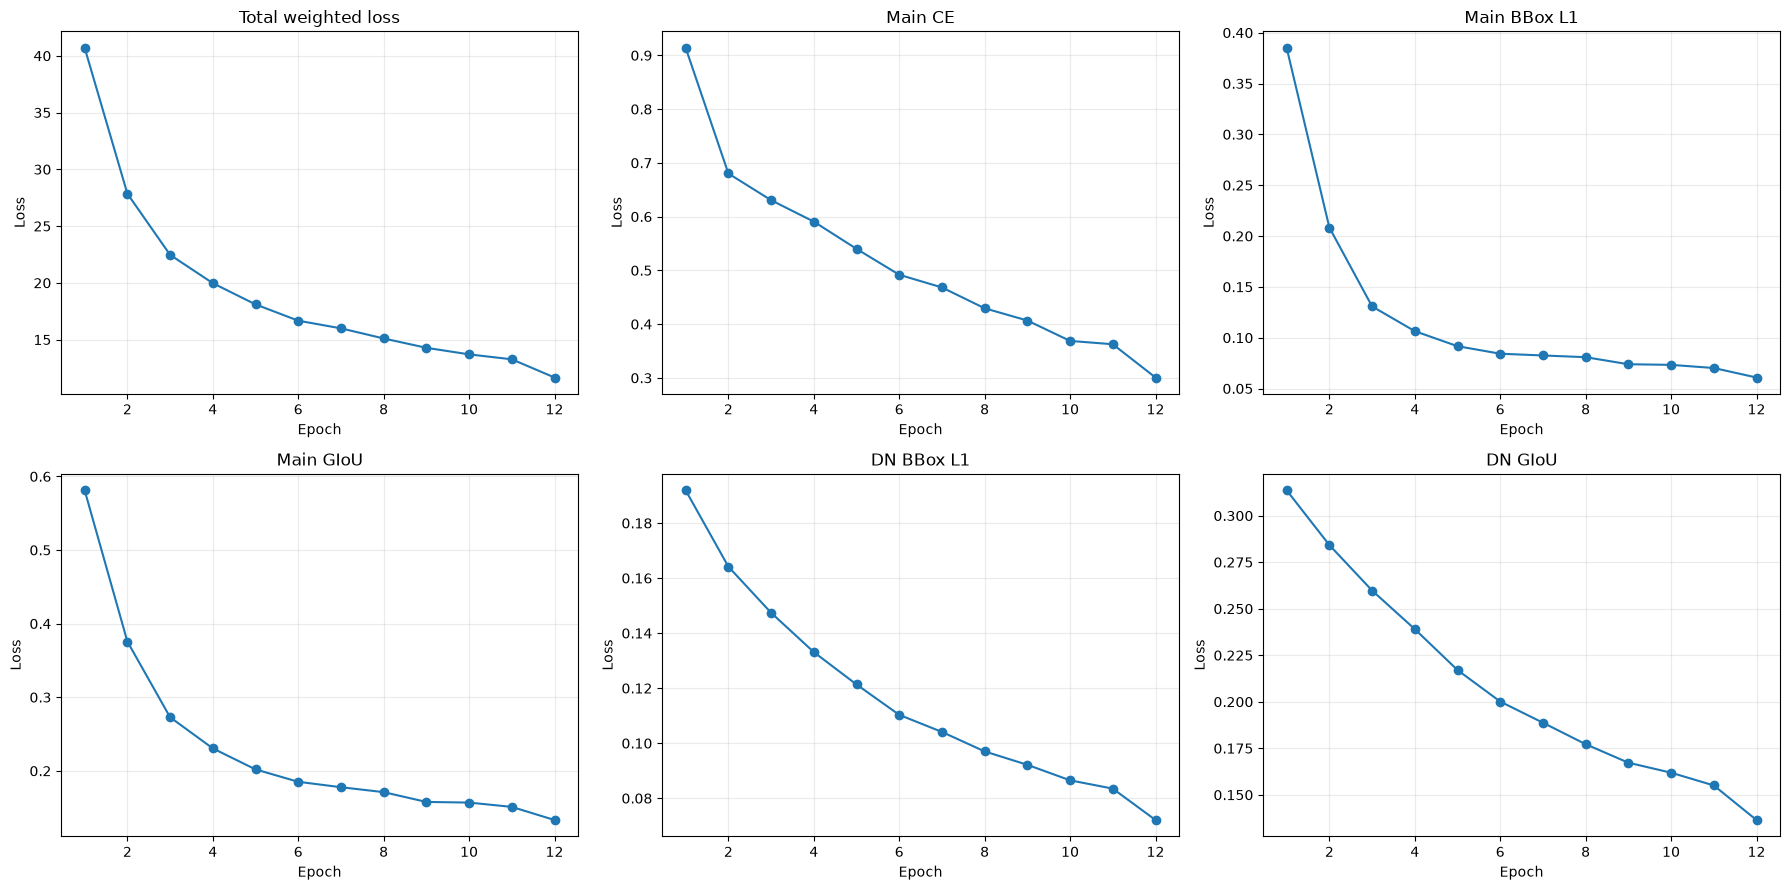

In [4]:
plot_history(config.history_path);

epochs = [row['epoch'] for row in history]
figure, axes = plt.subplots(2, 3, figsize=(18, 9))
for axis, key, title in (
    (axes[0, 0], 'loss', 'Total weighted loss'),
    (axes[0, 1], 'loss_ce', 'Main CE'),
    (axes[0, 2], 'loss_bbox', 'Main BBox L1'),
    (axes[1, 0], 'loss_giou', 'Main GIoU'),
    (axes[1, 1], 'loss_bbox_dn', 'DN BBox L1'),
    (axes[1, 2], 'loss_giou_dn', 'DN GIoU'),
):
    axis.plot(epochs, [row.get(key, np.nan) for row in history], marker='o')
    axis.set(title=title, xlabel='Epoch', ylabel='Loss')
    axis.grid(alpha=0.25)
figure.tight_layout()

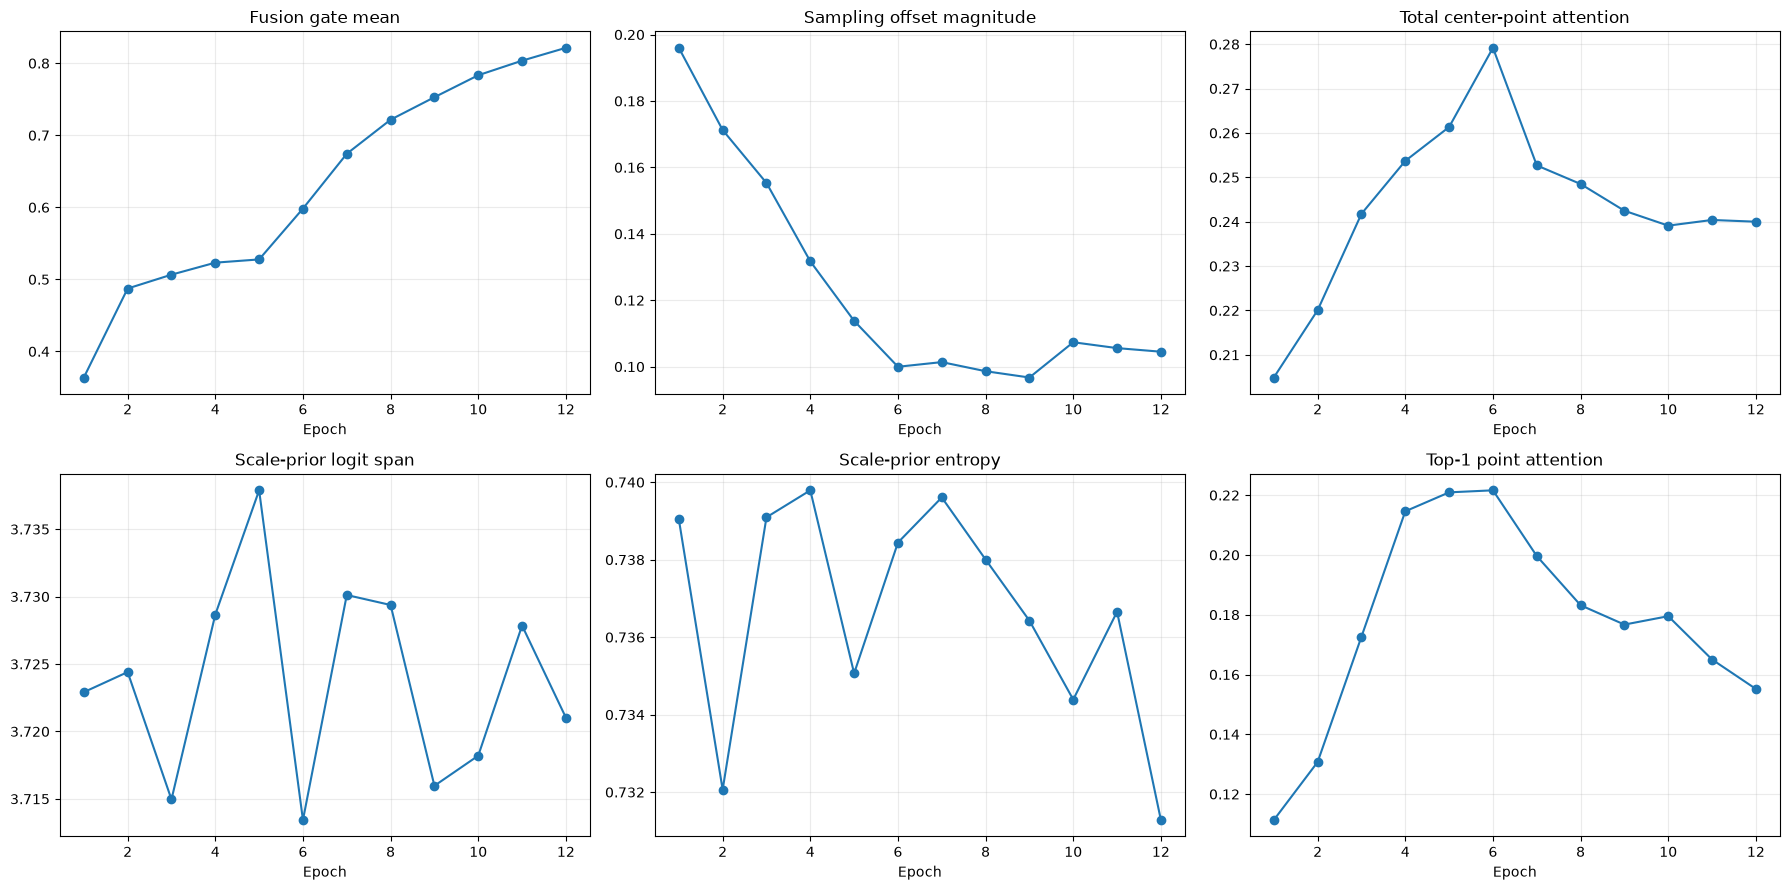

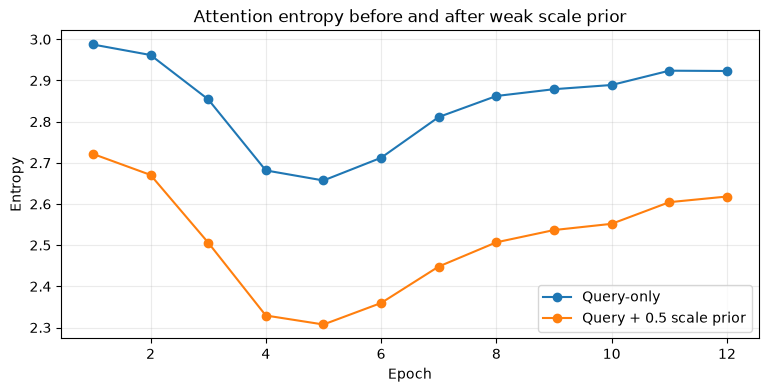

In [5]:
figure, axes = plt.subplots(2, 3, figsize=(18, 9))
for axis, key, title in (
    (axes[0, 0], 'bqr_gate_mean', 'Fusion gate mean'),
    (axes[0, 1], 'bqr_offset_abs_mean', 'Sampling offset magnitude'),
    (axes[0, 2], 'bqr_center_attention', 'Total center-point attention'),
    (axes[1, 0], 'bqr_scale_logit_span', 'Scale-prior logit span'),
    (axes[1, 1], 'bqr_scale_prior_entropy', 'Scale-prior entropy'),
    (axes[1, 2], 'bqr_top1_attention', 'Top-1 point attention'),
):
    axis.plot(epochs, [row.get(key, np.nan) for row in history], marker='o')
    axis.set(title=title, xlabel='Epoch')
    axis.grid(alpha=0.25)
figure.tight_layout()

figure, axis = plt.subplots(figsize=(9, 4))
axis.plot(epochs, [row.get('bqr_query_attention_entropy', np.nan) for row in history], marker='o', label='Query-only')
axis.plot(epochs, [row.get('bqr_final_attention_entropy', np.nan) for row in history], marker='o', label='Query + 0.5 scale prior')
axis.set(title='Attention entropy before and after weak scale prior', xlabel='Epoch', ylabel='Entropy')
axis.grid(alpha=0.25)
axis.legend();

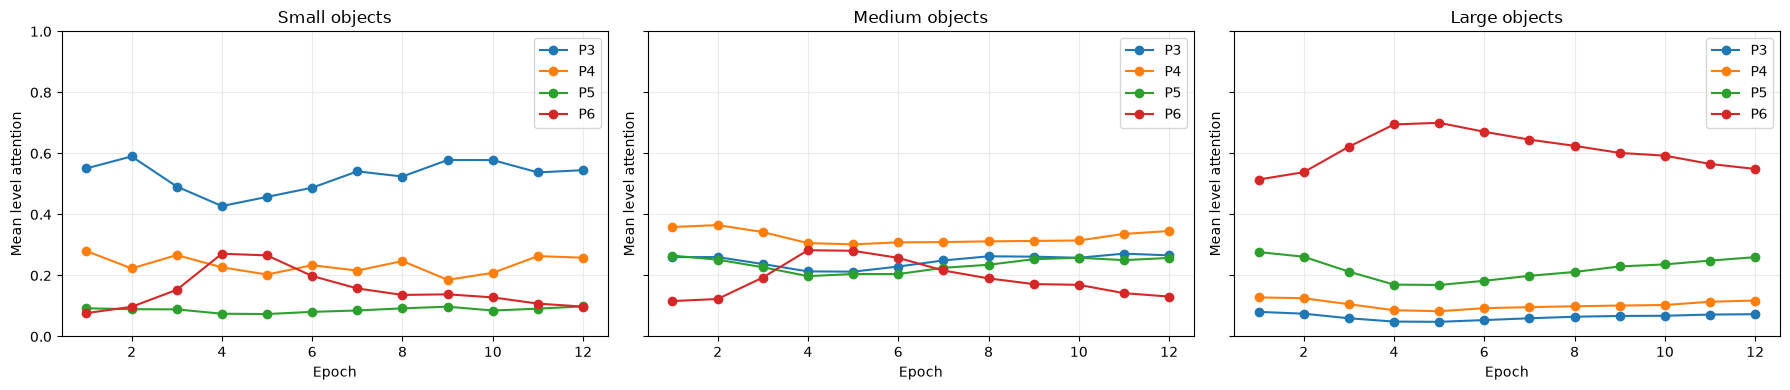

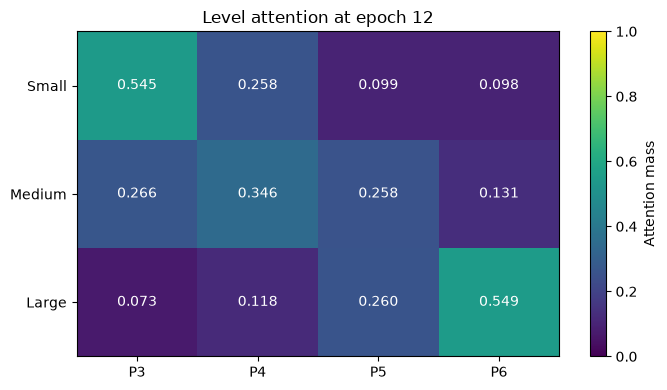

: 

In [ ]:
size_names = ('small', 'medium', 'large')
level_labels = ('P3', 'P4', 'P5', 'P6')
colors = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red')

figure, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for axis, size_name in zip(axes, size_names):
    for level, (label, color) in enumerate(zip(level_labels, colors)):
        key = f'bqr_{size_name}_level_{level}_attention'
        axis.plot(epochs, [row.get(key, np.nan) for row in history], marker='o', label=label, color=color)
    axis.set(title=f'{size_name.title()} objects', xlabel='Epoch', ylabel='Mean level attention')
    axis.set_ylim(0.0, 1.0)
    axis.grid(alpha=0.25)
    axis.legend()
figure.tight_layout()

latest_level_attention = np.array([
    [history[-1].get(f'bqr_{size_name}_level_{level}_attention', np.nan) for level in range(4)]
    for size_name in size_names
])
figure, axis = plt.subplots(figsize=(7, 4))
image = axis.imshow(latest_level_attention, vmin=0.0, vmax=1.0, cmap='viridis', aspect='auto')
axis.set_xticks(range(4), level_labels)
axis.set_yticks(range(3), [name.title() for name in size_names])
axis.set_title(f'Level attention at epoch {history[-1]["epoch"]}')
for row_index in range(3):
    for level in range(4):
        value = latest_level_attention[row_index, level]
        axis.text(level, row_index, f'{value:.3f}', ha='center', va='center', color='white' if value < 0.55 else 'black')
figure.colorbar(image, ax=axis, label='Attention mass')
figure.tight_layout()